## write a python program to implement K-Means clustering algorithm vary the number of k values as follows i.1  ii.3  iii.5

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

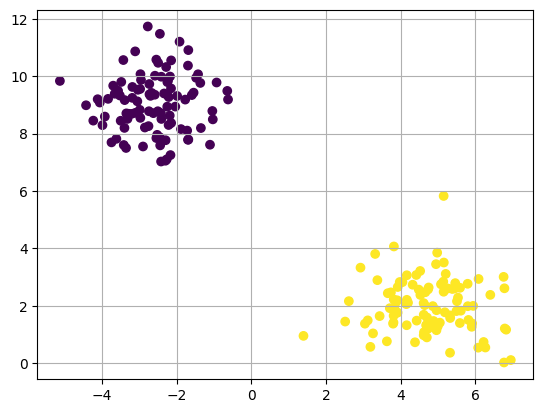

In [59]:
x,y=make_blobs(n_samples=200,n_features=2 ,centers=2, random_state=42)
fig=plt.figure(0)
plt.grid(True)
plt.scatter(x[:,0],x[:,1],c=y)
plt.show()

In [60]:
k=1

clusters={}
np.random.seed(42)
for idx in range(k):
    center=2*(2*np.random.random((x.shape[1],))-1)
    points=[]
    cluster={
        'center':center,
        'points':[]
    }
    clusters[idx] = cluster
clusters

{0: {'center': array([-0.50183952,  1.80285723]), 'points': []}}

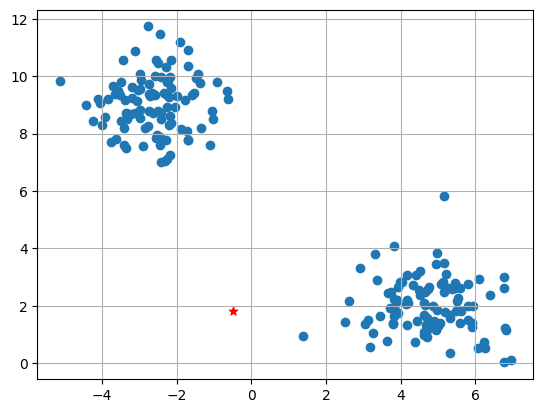

In [61]:
plt.scatter(x[:,0],x[:,1])
plt.grid(True)
for i in clusters:
    center=clusters[i]['center']
    plt.scatter(center[0],center[1],c='red',marker='*')
plt.show()

In [62]:
def  distance(a,b):
    return np.sqrt(np.sum((a-b)**2))

In [63]:
def assign_clusters(x,clusters):
    for idx in range(x.shape[0]):
        curr_x=x[idx]
        dist=[]
        for i in range(k):
            dis=distance(curr_x,clusters[i]['center'])
            dist.append(dis)
        curr_cluster=np.argmin(dist)
        clusters[curr_cluster]['points'].append(idx)
    return clusters

In [64]:
def update_clusters(x,clusters):
    for i in range(k):
        points=np.array(clusters[i]['points'])
        if points.shape[0]>0:
            new_center=np.mean(x[points],axis=0)
            clusters[i]['center']=new_center
            clusters[i]['points']=[]
    return clusters

In [65]:
def pred_cluster(x,clusters):
    pred=[]
    for i in range(x.shape[0]):
        dist=[]
        for j in range(k):
            dist.append(distance(x[i],clusters[j]['center']))
        pred.append(np.argmin(dist))
    return pred

In [66]:
clusters=assign_clusters(x,clusters)
clusters=update_clusters(x,clusters)
pred=pred_cluster(x,clusters)


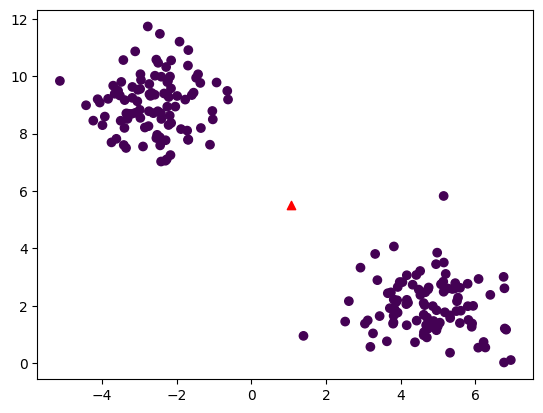

In [67]:
plt.scatter(x[:,0],x[:,1],c=pred)
for i in clusters:
    center=clusters[i]['center']
    plt.scatter(center[0],center[1],c='red',marker='^')
plt.show()